# Lennard-Jones MD plotting notebook

Run the **Load all saved data** cell once after the calculation script has finished.  
Each later plotting section can then be executed independently.

# Load all saved data

In [1]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Change this path only when the results folder is elsewhere.
RESULTS_DIR = Path("results")

metadata_file = RESULTS_DIR / "simulation_metadata.npz"
if not metadata_file.exists():
    raise FileNotFoundError(
        f"Could not find {metadata_file.resolve()}. "
        "Run cell_algorithm_calculations_and_saving.py first or change RESULTS_DIR."
    )

with np.load(metadata_file) as metadata:
    temperatures = metadata["temperatures"].astype(float)
    block_divisions = metadata["block_divisions"].astype(int)
    density_min = float(metadata["density_min"])
    density_max = float(metadata["density_max"])
    density_bins = int(metadata["density_bins"])
    N = int(metadata["N"])
    box = metadata["box"].astype(float)
    dt = float(metadata["dt"])
    steps = int(metadata["steps"])
    sample_every = int(metadata["sample_every"])
    trajectory_every = int(metadata["trajectory_every"])
    equilibration_steps = int(metadata["equilibration_steps"])
    density_every = int(metadata["density_every"])

Lx, Ly, Lz = box

def temperature_tag(temperature):
    return f"T{temperature:g}".replace(".", "p")

all_measurements = {}
all_density_histograms = {}

for temperature in temperatures:
    tag = temperature_tag(temperature)

    measurement_file = RESULTS_DIR / f"measurements_{tag}.txt"
    histogram_file = RESULTS_DIR / f"local_density_hist_{tag}.txt"

    if not measurement_file.exists():
        raise FileNotFoundError(f"Missing measurement file: {measurement_file}")
    if not histogram_file.exists():
        raise FileNotFoundError(f"Missing density histogram file: {histogram_file}")

    all_measurements[temperature] = np.loadtxt(measurement_file)

    histogram_table = np.loadtxt(histogram_file)
    # First column contains density-bin centers; the remaining columns are
    # histogram counts for the different block divisions.
    all_density_histograms[temperature] = histogram_table[:, 1:].T.astype(float)

binder_table = np.loadtxt(
    RESULTS_DIR / "binder_parameter_vs_temperature.txt"
)
surface_tension_table = np.loadtxt(
    RESULTS_DIR / "surface_tension_vs_temperature.txt"
)

binder_temperatures = binder_table[:, 0]
binder_values = binder_table[:, 1:]

surface_temperatures = surface_tension_table[:, 0]
surface_tension = surface_tension_table[:, 1]
surface_tension_error = surface_tension_table[:, 2]

density_edges = np.linspace(density_min, density_max, density_bins + 1)
density_centers = 0.5 * (density_edges[:-1] + density_edges[1:])
density_bin_width = density_edges[1] - density_edges[0]

print(f"Loaded {len(temperatures)} temperatures from {RESULTS_DIR.resolve()}")
print("Temperatures:", temperatures)
print("Block divisions:", block_divisions.tolist())


Loaded 23 temperatures from /Users/yanamuratova/Library/Mobile Documents/com~apple~CloudDocs/Computational Physics II/Project/CP2-Project-1/results
Temperatures: [0.74 0.8  0.86 0.9  0.94 0.98 1.   1.02 1.04 1.06 1.08 1.09 1.1  1.11
 1.12 1.13 1.14 1.15 1.16 1.17 1.18 1.19 1.2 ]
Block divisions: [[4, 2, 2], [6, 3, 3], [8, 4, 4]]


# Conservation of total energy and momentum

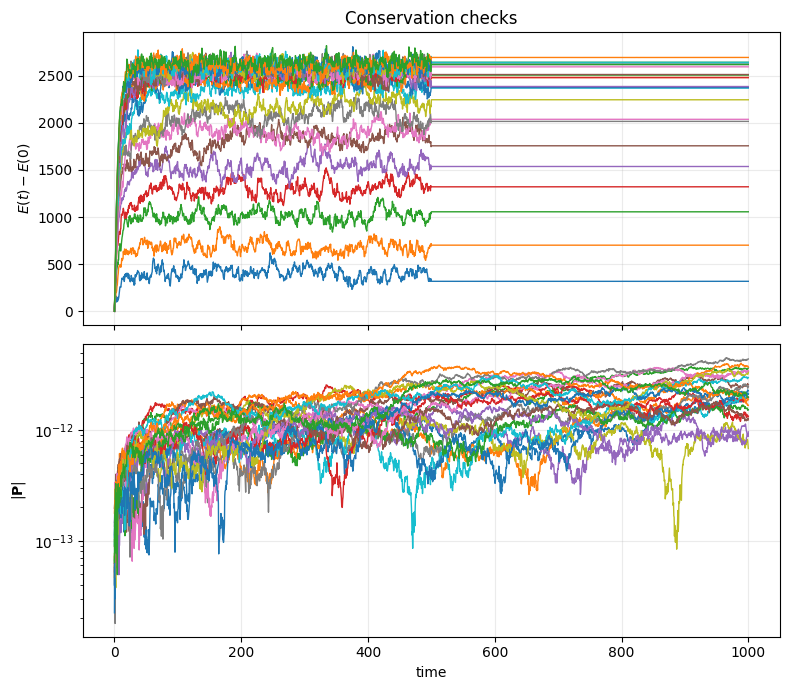

In [3]:

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

for temperature in temperatures:
    values = all_measurements[temperature]
    label = rf"$T_0={temperature:g}$"

    energy0 = values[0, 3]
    axes[0].plot(
        values[:, 1],
        values[:, 3] - energy0,
        linewidth=1,
        label=label,
    )

    momentum_norm = np.linalg.norm(values[:, 6:9], axis=1)
    axes[1].semilogy(
        values[:, 1],
        np.maximum(momentum_norm, 1e-18),
        linewidth=1,
        label=label,
    )

axes[0].set_ylabel(r"$E(t)-E(0)$")
axes[0].set_title("Conservation checks")
axes[0].grid(alpha=0.25)
#axes[0].legend()

axes[1].set_xlabel("time")
axes[1].set_ylabel(r"$|\mathbf{P}|$")
axes[1].grid(alpha=0.25)
#axes[1].legend()

fig.tight_layout()
fig.savefig(RESULTS_DIR / "conservation.png", dpi=180)
plt.show()


# Temperature and potential-energy time series

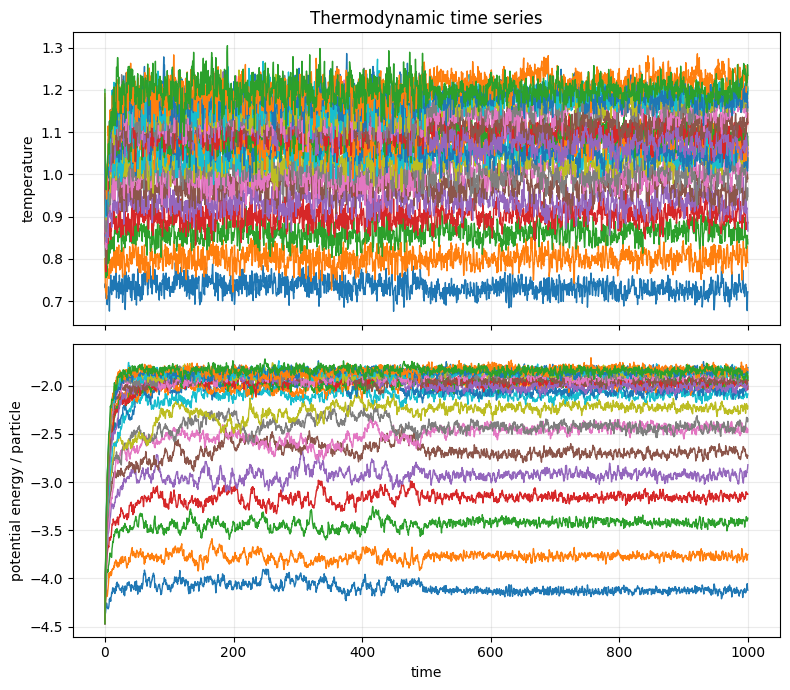

In [4]:

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

for temperature in temperatures:
    values = all_measurements[temperature]
    label = rf"$T_0={temperature:g}$"

    axes[0].plot(values[:, 1], values[:, 2], linewidth=1, label=label)
    axes[1].plot(
        values[:, 1],
        values[:, 5] / N,
        linewidth=1,
        label=label,
    )

axes[0].set_ylabel("temperature")
axes[0].set_title("Thermodynamic time series")
axes[0].grid(alpha=0.25)
#axes[0].legend()

axes[1].set_xlabel("time")
axes[1].set_ylabel("potential energy / particle")
axes[1].grid(alpha=0.25)
#axes[1].legend()

fig.tight_layout()
fig.savefig(RESULTS_DIR / "thermodynamics.png", dpi=180)
plt.show()


# Local-density distributions for all temperatures

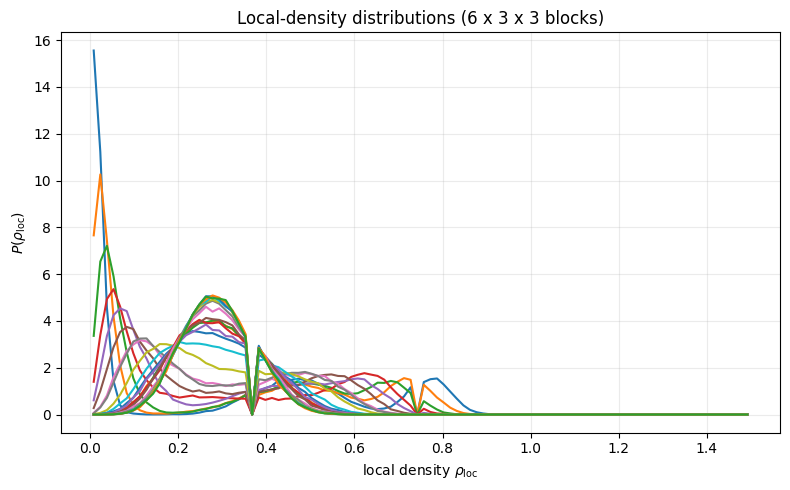

In [6]:

# Select which block division to plot: 0, 1, or 2.
partition_index = 1
partition_index = min(partition_index, len(block_divisions) - 1)

fig, ax = plt.subplots(figsize=(8, 5))

for temperature in temperatures:
    counts = all_density_histograms[temperature][partition_index]
    normalization = np.sum(counts) * density_bin_width
    probability_density = (
        counts / normalization if normalization > 0.0 else counts
    )
    ax.plot(
        density_centers,
        probability_density,
        label=rf"$T={temperature:g}$",
    )

nx, ny, nz = block_divisions[partition_index]
ax.set_xlabel(r"local density $\rho_{\mathrm{loc}}$")
ax.set_ylabel(r"$P(\rho_{\mathrm{loc}})$")
ax.set_title(f"Local-density distributions ({nx} x {ny} x {nz} blocks)")
ax.grid(alpha=0.25)
#ax.legend()

fig.tight_layout()
fig.savefig(RESULTS_DIR / "local_density_histograms.png", dpi=180)
plt.show()


# Local-density distribution versus temperature

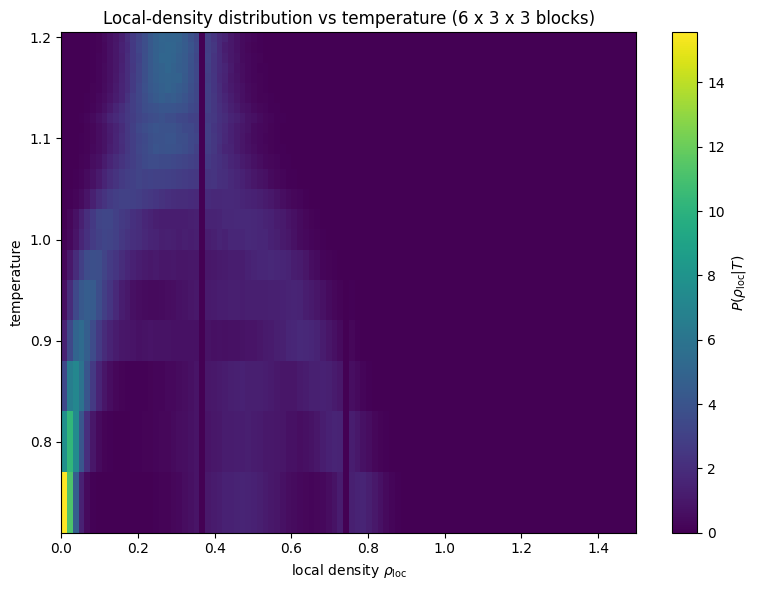

In [7]:

partition_index = 1
partition_index = min(partition_index, len(block_divisions) - 1)

probability = np.zeros((len(temperatures), density_bins), dtype=float)

for i, temperature in enumerate(temperatures):
    counts = all_density_histograms[temperature][partition_index]
    normalization = np.sum(counts) * density_bin_width
    if normalization > 0.0:
        probability[i] = counts / normalization

if len(temperatures) == 1:
    temperature_edges = np.array(
        [temperatures[0] - 0.5, temperatures[0] + 0.5]
    )
else:
    temperature_edges = np.empty(len(temperatures) + 1)
    temperature_edges[1:-1] = 0.5 * (
        temperatures[:-1] + temperatures[1:]
    )
    temperature_edges[0] = temperatures[0] - 0.5 * (
        temperatures[1] - temperatures[0]
    )
    temperature_edges[-1] = temperatures[-1] + 0.5 * (
        temperatures[-1] - temperatures[-2]
    )

fig, ax = plt.subplots(figsize=(8, 6))
mesh = ax.pcolormesh(
    density_edges,
    temperature_edges,
    probability,
    shading="auto",
)
fig.colorbar(mesh, ax=ax, label=r"$P(\rho_{\mathrm{loc}}|T)$")

nx, ny, nz = block_divisions[partition_index]
ax.set_xlabel(r"local density $\rho_{\mathrm{loc}}$")
ax.set_ylabel("temperature")
ax.set_title(
    f"Local-density distribution vs temperature "
    f"({nx} x {ny} x {nz} blocks)"
)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "local_density_vs_temperature.png", dpi=180)
plt.show()

table = np.column_stack((temperatures, probability))
header = "temperature " + " ".join(
    f"P_rho_{rho:.8g}" for rho in density_centers
)
np.savetxt(
    RESULTS_DIR / "local_density_vs_temperature.txt",
    table,
    header=header,
)


# Gas-liquid phase boundary

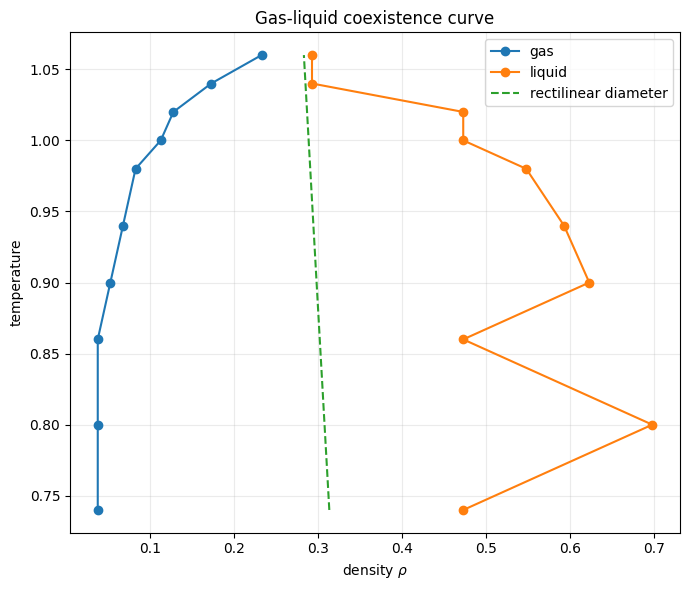

In [8]:

partition_index = 1
partition_index = min(partition_index, len(block_divisions) - 1)

temperatures_out = []
gas_densities = []
liquid_densities = []

mean_density = N / (Lx * Ly * Lz)
split = np.searchsorted(density_centers, mean_density)

for temperature in temperatures:
    counts = all_density_histograms[temperature][partition_index]

    if np.sum(counts) == 0.0 or split < 3 or split > density_bins - 3:
        continue

    smooth = np.convolve(counts, np.ones(5) / 5.0, mode="same")
    gas_index = int(np.argmax(smooth[:split]))
    liquid_index = split + int(np.argmax(smooth[split:]))

    if (
        density_centers[liquid_index] - density_centers[gas_index]
        < 3.0 * density_bin_width
    ):
        continue

    temperatures_out.append(temperature)
    gas_densities.append(density_centers[gas_index])
    liquid_densities.append(density_centers[liquid_index])

temperatures_out = np.asarray(temperatures_out, dtype=float)
gas_densities = np.asarray(gas_densities, dtype=float)
liquid_densities = np.asarray(liquid_densities, dtype=float)

if temperatures_out.size == 0:
    raise RuntimeError(
        "No resolved gas and liquid peaks were found for this block division."
    )

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(gas_densities, temperatures_out, "o-", label="gas")
ax.plot(liquid_densities, temperatures_out, "o-", label="liquid")

diameter = 0.5 * (gas_densities + liquid_densities)
if temperatures_out.size >= 2:
    coefficients = np.polyfit(temperatures_out, diameter, 1)
    temperature_line = np.linspace(
        temperatures_out.min(),
        temperatures_out.max(),
        100,
    )
    density_line = np.polyval(coefficients, temperature_line)
    ax.plot(
        density_line,
        temperature_line,
        "--",
        label="rectilinear diameter",
    )

ax.set_xlabel(r"density $\rho$")
ax.set_ylabel("temperature")
ax.set_title("Gas-liquid coexistence curve")
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(RESULTS_DIR / "phase_boundary_fig4.png", dpi=180)
plt.show()

np.savetxt(
    RESULTS_DIR / "phase_boundary_fig4.txt",
    np.column_stack(
        (temperatures_out, gas_densities, liquid_densities)
    ),
    header="temperature rho_g rho_l",
)


# Binder parameter and crossing estimate

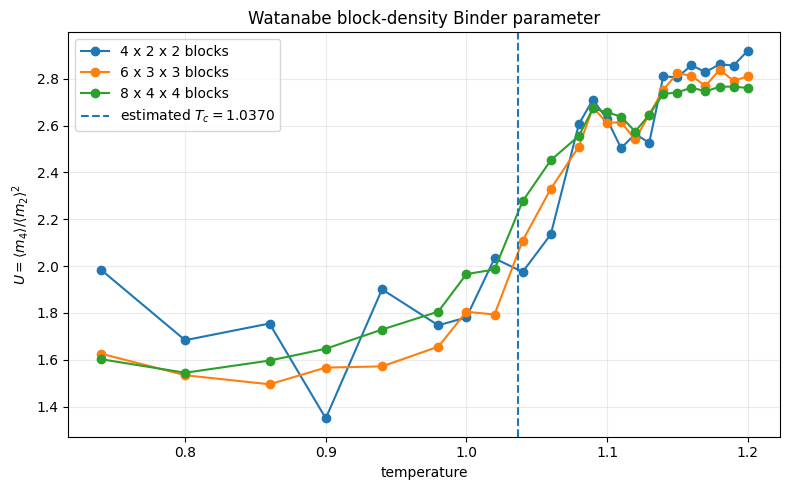

Pairwise crossing estimates: [0.88179663 0.91588526 0.99579843 1.00184017 1.03284498 1.0733948
 1.10120059 1.11827763 1.12161413 1.13679996 1.14775747 1.15270654
 0.87390653 0.92535042 0.96984029 1.01591816 1.0227161  1.07725897
 1.09560431 1.13615446 0.78137563 1.0893179  1.09069178 1.1297883 ]
Mean crossing temperature: 1.0369933096289563


In [9]:

def estimate_binder_crossings(temperature_values, curves):
    crossings = []

    for a in range(curves.shape[1]):
        for b in range(a + 1, curves.shape[1]):
            difference = curves[:, a] - curves[:, b]

            for i in range(len(temperature_values) - 1):
                d0 = difference[i]
                d1 = difference[i + 1]

                if not np.isfinite(d0) or not np.isfinite(d1):
                    continue

                if d0 == 0.0:
                    crossings.append(temperature_values[i])
                elif d0 * d1 < 0.0:
                    t0 = temperature_values[i]
                    t1 = temperature_values[i + 1]
                    t_cross = t0 - d0 * (t1 - t0) / (d1 - d0)
                    crossings.append(t_cross)

    return np.asarray(crossings, dtype=float)

fig, ax = plt.subplots(figsize=(8, 5))

for p, (nx, ny, nz) in enumerate(block_divisions):
    ax.plot(
        binder_temperatures,
        binder_values[:, p],
        "o-",
        label=f"{nx} x {ny} x {nz} blocks",
    )

crossings = estimate_binder_crossings(
    binder_temperatures,
    binder_values,
)

critical_temperature = np.nan
if crossings.size > 0:
    critical_temperature = float(np.mean(crossings))
    ax.axvline(
        critical_temperature,
        linestyle="--",
        label=rf"estimated $T_c={critical_temperature:.4f}$",
    )

ax.set_xlabel("temperature")
ax.set_ylabel(r"$U=\langle m_4\rangle/\langle m_2\rangle^2$")
ax.set_title("Watanabe block-density Binder parameter")
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(
    RESULTS_DIR / "binder_parameter_vs_temperature.png",
    dpi=180,
)
plt.show()

print("Pairwise crossing estimates:", crossings)
print("Mean crossing temperature:", critical_temperature)


# Surface tension versus reduced temperature

Fitted exponent 2 nu = 0.712100
Fitted nu = 0.356050


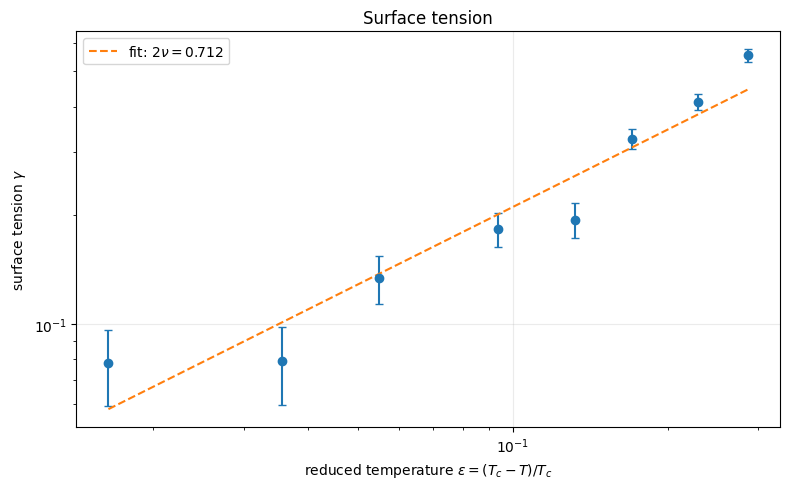

In [11]:

# Use the Binder estimate when it is available; otherwise set Tc manually.
try:
    Tc = float(critical_temperature)
except NameError:
    Tc = np.nan

if not np.isfinite(Tc):
    Tc = 1.10

epsilon = (Tc - surface_temperatures) / Tc
mask = (
    (epsilon > 0.0)
    & (surface_tension > 0.0)
    & np.isfinite(surface_tension)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    epsilon[mask],
    surface_tension[mask],
    yerr=surface_tension_error[mask],
    fmt="o",
    capsize=3,
)

if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(
        np.log(epsilon[mask]),
        np.log(surface_tension[mask]),
        1,
    )
    epsilon_fit = np.logspace(
        np.log10(np.min(epsilon[mask])),
        np.log10(np.max(epsilon[mask])),
        100,
    )
    ax.plot(
        epsilon_fit,
        np.exp(intercept) * epsilon_fit**slope,
        "--",
        label=rf"fit: $2\nu={slope:.3f}$",
    )
    ax.legend()
    print(f"Fitted exponent 2 nu = {slope:.6f}")
    print(f"Fitted nu = {0.5 * slope:.6f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"reduced temperature $\epsilon=(T_c-T)/T_c$")
ax.set_ylabel(r"surface tension $\gamma$")
ax.set_title(
    r"Surface tension"
)
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(
    RESULTS_DIR / "surface_tension_vs_temperature.png",
    dpi=180,
)
plt.show()
